In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from fredapi import Fred
import itertools
import ipywidgets as widgets
from ipywidgets import interact
from sklearn.preprocessing import StandardScaler
#downloaded all the dependencies

In [2]:
gold = yf.Ticker("GLD")
euro = yf.Ticker("^STOXX50E")
fx = yf.Ticker("JPY=X")
ief = yf.Ticker("IEF")
gspc = yf.Ticker("^GSPC")
oil = yf.Ticker("CL=F")
nikki = yf.Ticker("^N225")
copper = yf.Ticker("CPER")

In [3]:
final_data = yf.download(tickers=["^GSPC", "CL=F", "^N225", "CPER", "GLD", "IEF", "JPY=X", "^STOXX50E"], start="2024-02-09", end="2026-02-09")
final_data.ffill(inplace=True)
final_data.bfill(inplace=True)
new_closed_data = final_data['Close']
new_normalized = new_closed_data/new_closed_data.iloc[0]

[*********************100%***********************]  8 of 8 completed


In [8]:
new_log_returns = np.log(final_data['Close']).diff()
new_log_returns.ffill(inplace = True)
new_log_returns.bfill(inplace = True)

all_roll_corr = new_log_returns.rolling(window=30).corr()
all_roll_corr.dropna(inplace=True)


In [5]:
dates = all_roll_corr.index.get_level_values(0).unique()
@interact(date_index = widgets.IntSlider(min=0, max = len(dates)-1, step=1, value = 0, description = 'Timeline'))

#defining function to get heatmap using interact
def plot_rolling_heatmap(date_index):
    target_date = dates[date_index]
    matrix_frame = all_roll_corr.loc[target_date]
    
    plt.figure(figsize= (20,10))
    sns.heatmap(data=matrix_frame, annot = True,
                fmt = ".2f", cmap = 'coolwarm',
                vmax=1, vmin=-1, center = 0)
    plt.title(f"Rolling function heatmap: {target_date.strftime('%Y-%m-%d')}")
    plt.show()

interactive(children=(IntSlider(value=0, description='Timeline', max=489), Output()), _dom_classes=('widget-in…

In [6]:
#This is the basic idea of the heatmap - we can enhance it by applying PCA and absorption ratio
# Lets do that next, but the basic idea of the heatmap has been completed.

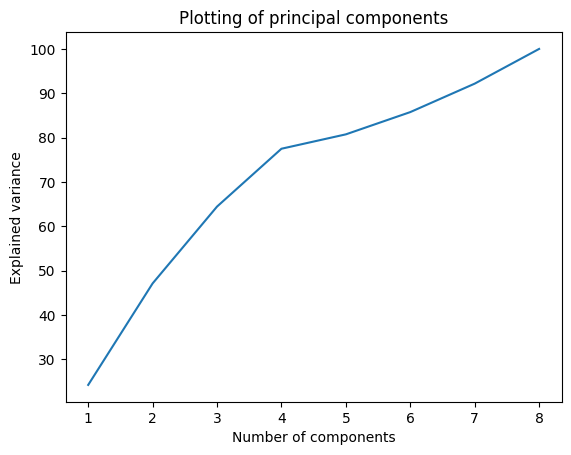

In [17]:
X = all_roll_corr.iloc[:, 0:8].values
X = StandardScaler().fit_transform(X)
#find the covariance matrix and then the eigen values
covariance_X = np.cov(X.T)

eigen_values, eigen_vectors = np.linalg.eig(covariance_X)
#Now we find the singular value decomposition of the matrix

svd, s, v  = np.linalg.svd(X.T) 

#Now find the principal components using the concept of explained variance

explained_variance =[(i/sum(eigen_values))*100 for i in eigen_values]
cumulative_variance = np.cumsum(explained_variance)

#Now we plot the principal components 
sns.lineplot(x=[1,2,3,4,5,6,7,8], y=cumulative_variance)
plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.title("Plotting of principal components")
plt.show()